# Target Problem

The project proposes to use a deep reinforcement learning framework to learn a profitable stock trading strategy, with the goal to optimize the cumulative return and Alpha. It would select S&P500 Index with the top 20 market capitalization stocks as our trading stock pool. The input to the algorithm is the market trend for these stocks in the last month, remaining balance, and current portfolio. The model agent output is a series of trading actions among stocks. The available trading
action options are: sell, buy and hold. The market data in the most recent months will be used to feed
the model performance evaluation.

The algorithm is trained using Deep Reinforcement Learning (DRL) algorithms and the components of the reinforcement learning environment are:

* Action: The action space describes the allowed actions that the agent interacts with the
environment. Normally, a ∈ A includes three actions: a ∈ {−1, 0, 1}, where −1, 0, 1 represent
selling, holding, and buying one stock. Also, an action can be carried upon multiple shares. We use
an action space {−k, ..., −1, 0, 1, ..., k}, where k denotes the number of shares. For example, "Buy
10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or −10, respectively

* Reward function: r(s, a, s′) is the incentive mechanism for an agent to learn a better action. The change of the portfolio value when action a is taken at state s and arriving at new state s',  i.e., r(s, a, s′) = v′ − v, where v′ and v represent the portfolio
values at state s′ and s, respectively

* State: The state space describes the observations that the agent receives from the environment. Just as a human trader needs to analyze various information before executing a trade, so
our trading agent observes many different features to better learn in an interactive environment.

* Environment: SP500 top 20 companies


The data of the single stock that we will be using for this case study is obtained from Yahoo Finance API. The data contains Open-High-Low-Close price and volume.


## Environment Setup

### Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import datetime

%matplotlib inline
from rl.config import config
from rl.marketdata.yahoodownloader import YahooDownloader
from rl.preprocessing.preprocessors import FeatureEngineer
from rl.preprocessing.data import data_split
from rl.env.env_stocktrading import StockTradingEnv
from rl.model.models import DRLAgent
from rl.trade.backtest import backtest_stats, backtest_plot, get_daily_return, get_baseline

from pprint import pprint

import itertools

D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pyfolio\pos.py:26: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


### Cache Folders

In [2]:
import os
if not os.path.exists("./" + config.DATA_SAVE_DIR):
    os.makedirs("./" + config.DATA_SAVE_DIR)
if not os.path.exists("./" + config.TRAINED_MODEL_DIR):
    os.makedirs("./" + config.TRAINED_MODEL_DIR)
if not os.path.exists("./" + config.TENSORBOARD_LOG_DIR):
    os.makedirs("./" + config.TENSORBOARD_LOG_DIR)
if not os.path.exists("./" + config.RESULTS_DIR):
    os.makedirs("./" + config.RESULTS_DIR)

### Fetch Data

In [3]:
# from config.py start_date is a string
start_date = config.START_DATE
# from config.py end_date is a string
end_date = config.END_DATE
# from config.py split_date is a string
split_date = config.SPLIT_DATE
# config target ticker
target_ticker = config.SP500_20_TICKER
# config tech_indicator_list
tech_indicator_list = config.TECHNICAL_INDICATORS_LIST
print("training period: {}-{}, testing period: {}-{}\n".format(start_date, split_date, split_date, end_date))
print("target ticker list:\n {}\n".format(target_ticker))
print("tech_indicator_list:\n {}\n".format(tech_indicator_list))

training period: 2000-01-01-2019-01-01, testing period: 2019-01-01-2021-01-01

target ticker list:
 ['AAPL', 'MSFT', 'AMZN', 'BRK-B', 'JPM', 'JNJ', 'UNH', 'HD', 'PG', 'NVDA', 'DIS', 'BAC', 'CMCSA', 'XOM', 'VZ', 'T', 'ADBE', 'PFE', 'CSCO', 'INTC']

tech_indicator_list:
 ['macd', 'boll_ub', 'boll_lb', 'rsi_10', 'rsi_20', 'cci_10', 'cci_20', 'dx_30', 'close_20_sma', 'close_60_sma', 'close_120_sma', 'close_20_ema', 'close_60_ema', 'close_120_ema']



In [4]:
df = YahooDownloader(start_date = start_date,
                     end_date = end_date,
                     ticker_list = target_ticker).fetch_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [5]:
df.shape

(105680, 8)

In [6]:
df.sort_values(['date','tic'],ignore_index=True).head()

,date,open,high,low,close,volume,tic,day
0,2000-01-03,0.936384,1.004464,0.907924,0.859423,535796800.0,AAPL,0
1,2000-01-03,16.812500,16.875000,16.062500,16.274673,7384400.0,ADBE,0
2,2000-01-03,81.500000,89.562500,79.046875,89.375000,16117600.0,AMZN,0
3,2000-01-03,25.125000,25.125000,24.000000,13.952057,13705800.0,BAC,0
4,2000-01-03,36.500000,36.580002,34.820000,35.299999,875000.0,BRK-B,0


## Data Preprocessing
Data preprocessing is a crucial step for training a high quality machine learning model. We need to check for missing data and do feature engineering in order to convert the data into a model-ready state.
* Add technical indicators. In practical trading, various information needs to be taken into account, for example the historical stock prices, current holding shares, technical indicators, etc. In this article, we demonstrate two trend-following technical indicators: MACD and RSI.
* Add turbulence index. Risk-aversion reflects whether an investor will choose to preserve the capital. It also influences one's trading strategy when facing different market volatility level. To control the risk in a worst-case scenario, such as financial crisis of 2007–2008, FinRL employs the financial turbulence index that measures extreme asset price fluctuation.

### Feature Engineering

In [7]:
fe = FeatureEngineer(
                    use_technical_indicator=True,
                    tech_indicator_list = tech_indicator_list,
                    use_turbulence=True,
                    user_defined_feature = False)

processed = fe.preprocess_data(df)

Successfully added technical indicators
Successfully added turbulence index


In [8]:
processed.shape
processed.head()

,date,open,high,low,close,volume,tic,day,macd,boll_ub,...,cci_10,cci_20,dx_30,close_20_sma,close_60_sma,close_120_sma,close_20_ema,close_60_ema,close_120_ema,turbulence
0,2000-01-03,0.936384,1.004464,0.907924,0.859423,535796800.0,AAPL,0,0.0,0.925665,...,-66.666667,-66.666667,100.0,0.859423,0.859423,0.859423,0.859423,0.859423,0.859423,0.0
1,2000-01-03,16.812500,16.875000,16.062500,16.274673,7384400.0,ADBE,0,0.0,0.925665,...,-66.666667,-66.666667,100.0,16.274673,16.274673,16.274673,16.274673,16.274673,16.274673,0.0
2,2000-01-03,81.500000,89.562500,79.046875,89.375000,16117600.0,AMZN,0,0.0,0.925665,...,-66.666667,-66.666667,100.0,89.375000,89.375000,89.375000,89.375000,89.375000,89.375000,0.0
3,2000-01-03,25.125000,25.125000,24.000000,13.952057,13705800.0,BAC,0,0.0,0.925665,...,-66.666667,-66.666667,100.0,13.952057,13.952057,13.952057,13.952057,13.952057,13.952057,0.0
4,2000-01-03,36.500000,36.580002,34.820000,35.299999,875000.0,BRK-B,0,0.0,0.925665,...,-66.666667,-66.666667,100.0,35.299999,35.299999,35.299999,35.299999,35.299999,35.299999,0.0


### Data display

In [9]:
list_ticker = processed["tic"].unique().tolist()
list_date = list(pd.date_range(processed['date'].min(),processed['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination,columns=["date","tic"]).merge(processed,on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(processed['date'])]
processed_full = processed_full.sort_values(['date','tic'])
processed_full = processed_full.fillna(0)

In [10]:
processed_full.sort_values(['date','tic'],ignore_index=True).head(10)

,date,tic,open,high,low,close,volume,day,macd,boll_ub,...,cci_10,cci_20,dx_30,close_20_sma,close_60_sma,close_120_sma,close_20_ema,close_60_ema,close_120_ema,turbulence
0,2000-01-03,AAPL,0.936384,1.004464,0.907924,0.859423,535796800.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,0.859423,0.859423,0.859423,0.859423,0.859423,0.859423,0.0
1,2000-01-03,ADBE,16.812500,16.875000,16.062500,16.274673,7384400.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,16.274673,16.274673,16.274673,16.274673,16.274673,16.274673,0.0
2,2000-01-03,AMZN,81.500000,89.562500,79.046875,89.375000,16117600.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,89.375000,89.375000,89.375000,89.375000,89.375000,89.375000,0.0
3,2000-01-03,BAC,25.125000,25.125000,24.000000,13.952057,13705800.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,13.952057,13.952057,13.952057,13.952057,13.952057,13.952057,0.0
4,2000-01-03,BRK-B,36.500000,36.580002,34.820000,35.299999,875000.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,35.299999,35.299999,35.299999,35.299999,35.299999,35.299999,0.0
5,2000-01-03,CMCSA,16.145832,16.333332,15.062500,12.189544,2333700.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,12.189544,12.189544,12.189544,12.189544,12.189544,12.189544,0.0
6,2000-01-03,CSCO,54.968750,55.125000,51.781250,40.118656,53076000.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,40.118656,40.118656,40.118656,40.118656,40.118656,40.118656,0.0
7,2000-01-03,DIS,28.855125,29.533344,28.361876,23.115248,8402230.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,23.115248,23.115248,23.115248,23.115248,23.115248,23.115248,0.0
8,2000-01-03,HD,68.625000,69.187500,63.812500,42.563168,12030800.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,42.563168,42.563168,42.563168,42.563168,42.563168,42.563168,0.0
9,2000-01-03,INTC,41.632812,43.687500,41.625000,27.002798,57710200.0,0.0,0.0,0.925665,...,-66.666667,-66.666667,100.0,27.002798,27.002798,27.002798,27.002798,27.002798,27.002798,0.0


### Data Split

In [11]:
train = data_split(processed_full, start_date, split_date)
evaluate = data_split(processed_full, split_date, end_date)
print(train.shape)
print(evaluate.shape)

(95580, 23)
(10100, 23)


## RL Environment
Considering the stochastic and interactive nature of the automated stock trading tasks, a financial task is modeled as a **Markov Decision Process (MDP)** problem. The training process involves observing stock price change, taking an action and reward's calculation to have the agent adjusting its strategy accordingly. By interacting with the environment, the trading agent will derive a trading strategy with the maximized rewards as time proceeds.

Our trading environments, based on OpenAI Gym framework, simulate live stock markets with real market data according to the principle of time-driven simulation.

The action space describes the allowed actions that the agent interacts with the environment. Normally, action a includes three actions: {-1, 0, 1}, where -1, 0, 1 represent selling, holding, and buying one share. Also, an action can be carried upon multiple shares. We use an action space {-k,…,-1, 0, 1, …, k}, where k denotes the number of shares to buy and -k denotes the number of shares to sell. For example, "Buy 10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or -10, respectively. The continuous action space needs to be normalized to [-1, 1], since the policy is defined on a Gaussian distribution, which needs to be normalized and symmetric.

In [12]:
initialData = train.loc[0,:]
print(initialData)

         date    tic       open       high        low      close       volume  \
0  2000-01-03   AAPL   0.936384   1.004464   0.907924   0.859423  535796800.0   
0  2000-01-03   ADBE  16.812500  16.875000  16.062500  16.274673    7384400.0   
0  2000-01-03   AMZN  81.500000  89.562500  79.046875  89.375000   16117600.0   
0  2000-01-03    BAC  25.125000  25.125000  24.000000  13.952057   13705800.0   
0  2000-01-03  BRK-B  36.500000  36.580002  34.820000  35.299999     875000.0   
0  2000-01-03  CMCSA  16.145832  16.333332  15.062500  12.189544    2333700.0   
0  2000-01-03   CSCO  54.968750  55.125000  51.781250  40.118656   53076000.0   
0  2000-01-03    DIS  28.855125  29.533344  28.361876  23.115248    8402230.0   
0  2000-01-03     HD  68.625000  69.187500  63.812500  42.563168   12030800.0   
0  2000-01-03   INTC  41.632812  43.687500  41.625000  27.002798   57710200.0   
0  2000-01-03    JNJ  46.562500  46.875000  45.781250  26.644770    4642400.0   
0  2000-01-03    JPM  49.833

In [13]:
evaluate.head()

,date,tic,open,high,low,close,volume,day,macd,boll_ub,...,cci_10,cci_20,dx_30,close_20_sma,close_60_sma,close_120_sma,close_20_ema,close_60_ema,close_120_ema,turbulence
0,2019-01-02,AAPL,38.722500,39.712502,38.557499,38.439735,148158800.0,2.0,-2.013469,44.430054,...,5.338357,-62.506106,42.250808,39.907269,46.409359,48.900092,39.894455,44.458658,46.304234,40.714603
0,2019-01-02,ADBE,219.910004,226.169998,219.000000,224.570007,2784100.0,2.0,-5.282335,259.815658,...,42.283562,-46.078026,18.279805,231.481001,239.189334,249.605750,228.071064,238.013177,241.061149,40.714603
0,2019-01-02,AMZN,1465.199951,1553.359985,1460.930054,1539.130005,7983100.0,2.0,-46.142964,1783.043118,...,71.986956,-29.701621,16.053433,1558.427496,1640.886670,1772.662920,1531.028514,1632.326567,1675.234803,40.714603
0,2019-01-02,BAC,24.080000,25.139999,24.010000,23.649902,71836300.0,2.0,-0.669456,25.783587,...,82.345511,-11.196459,18.930726,23.473258,25.393073,27.097682,23.590685,25.158157,26.235524,40.714603
0,2019-01-02,BRK-B,201.729996,204.399994,201.149994,202.800003,4802100.0,2.0,-2.760708,215.345783,...,106.526697,18.020183,2.953389,201.200500,208.270668,208.078834,201.656593,206.289644,206.078162,40.714603


In [14]:
stock_dimension = len(train.tic.unique())
state_space = 1 + 2*stock_dimension + len(tech_indicator_list)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 20, State Space: 321


In [15]:
env_params = {
    "hmax": 100, 
    "initial_amount": 1000000, 
    "buy_cost_pct": 0.001,
    "sell_cost_pct": 0.001,
    "state_space": state_space, 
    "stock_dim": stock_dimension, 
    "tech_indicator_list": tech_indicator_list, 
    "action_space": stock_dimension, 
    "reward_scaling": 1e-6
}

e_train_gym = StockTradingEnv(df = train, **env_params)

[1000000, 0.859423041343689, 16.274673461914062, 89.375, 13.952056884765625, 35.29999923706055, 12.189543724060059, 40.118656158447266, 23.11524772644043, 42.563167572021484, 27.002798080444336, 26.6447696685791, 25.863813400268555, 36.93210220336914, 3.585430383682251, 14.565584182739258, 30.248369216918945, 15.941187858581543, 5.632353782653809, 20.573511123657227, 20.461938858032227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.720722899924667, 0.720722899924667, 0.720722899924667, 0.72072289992

## Environment for Training



In [16]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

[1000000, 0.859423041343689, 16.274673461914062, 89.375, 13.952056884765625, 35.29999923706055, 12.189543724060059, 40.118656158447266, 23.11524772644043, 42.563167572021484, 27.002798080444336, 26.6447696685791, 25.863813400268555, 36.93210220336914, 3.585430383682251, 14.565584182739258, 30.248369216918945, 15.941187858581543, 5.632353782653809, 20.573511123657227, 20.461938858032227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.720722899924667, 0.720722899924667, 0.720722899924667, 0.72072289992

## RL Models Training: (A2C DDPG, PPO, TD3, SAC)
* The implementation of the DRL algorithms are based on **OpenAI Baselines** and **Stable Baselines**. Stable Baselines is a fork of OpenAI Baselines, with a major structural refactoring, and code cleanups.
* FinRL library includes fine-tuned standard DRL algorithms, such as DQN, DDPG,
Multi-Agent DDPG, PPO, SAC, A2C and TD3. We also allow users to
design their own DRL algorithms by adapting these DRL algorithms.

### Actor-Critic


In [17]:
agent = DRLAgent(env = env_train)
A2C_PARAMS = {
    "n_steps": 5, 
    "ent_coef": 0.005, 
    "learning_rate": 0.0001
}
model_a2c = agent.get_model("a2c", model_kwargs = A2C_PARAMS)

{'n_steps': 5, 'ent_coef': 0.005, 'learning_rate': 0.0001}
Using cpu device


In [18]:
trained_a2c = agent.train_model(
    model=model_a2c, 
    tb_log_name='a2c',
    total_timesteps=100000)

[1000000, 0.859423041343689, 16.274673461914062, 89.375, 13.952056884765625, 35.29999923706055, 12.189543724060059, 40.118656158447266, 23.11524772644043, 42.563167572021484, 27.002798080444336, 26.6447696685791, 25.863813400268555, 36.93210220336914, 3.585430383682251, 14.565584182739258, 30.248369216918945, 15.941187858581543, 5.632353782653809, 20.573511123657227, 20.461938858032227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.720722899924667, 0.720722899924667, 0.720722899924667, 0.72072289992

------------------------------------
| time/                 |          |
|    fps                | 104      |
|    iterations         | 800      |
|    time_elapsed       | 38       |
|    total_timesteps    | 4000     |
| train/                |          |
|    entropy_loss       | -28.8    |
|    explained_variance | -42.3    |
|    learning_rate      | 0.0001   |
|    n_updates          | 799      |
|    policy_loss        | 4.44     |
|    std                | 1.02     |
|    value_loss         | 0.0467   |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 105      |
|    iterations         | 900      |
|    time_elapsed       | 42       |
|    total_timesteps    | 4500     |
| train/                |          |
|    entropy_loss       | -28.8    |
|    explained_variance | -221     |
|    learning_rate      | 0.0001   |
|    n_updates          | 899      |
|    policy_loss        | -2.75    |
|

------------------------------------
| time/                 |          |
|    fps                | 108      |
|    iterations         | 1200     |
|    time_elapsed       | 55       |
|    total_timesteps    | 6000     |
| train/                |          |
|    entropy_loss       | -28.9    |
|    explained_variance | -3.95    |
|    learning_rate      | 0.0001   |
|    n_updates          | 1199     |
|    policy_loss        | -9.28    |
|    std                | 1.02     |
|    value_loss         | 0.112    |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 108      |
|    iterations         | 1300     |
|    time_elapsed       | 59       |
|    total_timesteps    | 6500     |
| train/                |          |
|    entropy_loss       | -28.9    |
|    explained_variance | -191     |
|    learning_rate      | 0.0001   |
|    n_updates          | 1299     |
|    policy_loss        | -0.147   |
|

------------------------------------
| environment/          |          |
|    portfolio_value    | 3.49e+06 |
|    total_cost         | 2.29e+05 |
|    total_reward       | 2.49e+06 |
|    total_reward_pct   | 249      |
|    total_trades       | 90750    |
| time/                 |          |
|    fps                | 110      |
|    iterations         | 2000     |
|    time_elapsed       | 90       |
|    total_timesteps    | 10000    |
| train/                |          |
|    entropy_loss       | -29      |
|    explained_variance | -0.232   |
|    learning_rate      | 0.0001   |
|    n_updates          | 1999     |
|    policy_loss        | 0.224    |
|    std                | 1.03     |
|    value_loss         | 0.00042  |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 111      |
|    iterations         | 2100     |
|    time_elapsed       | 94       |
|    total_timesteps    | 10500    |
|

------------------------------------
| environment/          |          |
|    portfolio_value    | 4.51e+06 |
|    total_cost         | 2.21e+05 |
|    total_reward       | 3.51e+06 |
|    total_reward_pct   | 351      |
|    total_trades       | 89914    |
| time/                 |          |
|    fps                | 110      |
|    iterations         | 2900     |
|    time_elapsed       | 130      |
|    total_timesteps    | 14500    |
| train/                |          |
|    entropy_loss       | -29.2    |
|    explained_variance | -214     |
|    learning_rate      | 0.0001   |
|    n_updates          | 2899     |
|    policy_loss        | 1.59     |
|    std                | 1.04     |
|    value_loss         | 0.00781  |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 110      |
|    iterations         | 3000     |
|    time_elapsed       | 135      |
|    total_timesteps    | 15000    |
|

...

------------------------------------
| environment/          |          |
|    portfolio_value    | 3.48e+06 |
|    total_cost         | 1.4e+05  |
|    total_reward       | 2.48e+06 |
|    total_reward_pct   | 248      |
|    total_trades       | 79086    |
| time/                 |          |
|    fps                | 113      |
|    iterations         | 15300    |
|    time_elapsed       | 671      |
|    total_timesteps    | 76500    |
| train/                |          |
|    entropy_loss       | -32.4    |
|    explained_variance | 0        |
|    learning_rate      | 0.0001   |
|    n_updates          | 15299    |
|    policy_loss        | 0.103    |
|    std                | 1.22     |
|    value_loss         | 1.76e-05 |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 114      |
|    iterations         | 15400    |
|    time_elapsed       | 675      |
|    total_timesteps    | 77000    |
|

------------------------------------
| environment/          |          |
|    portfolio_value    | 3.3e+06  |
|    total_cost         | 1.93e+05 |
|    total_reward       | 2.3e+06  |
|    total_reward_pct   | 230      |
|    total_trades       | 84639    |
| time/                 |          |
|    fps                | 114      |
|    iterations         | 16300    |
|    time_elapsed       | 714      |
|    total_timesteps    | 81500    |
| train/                |          |
|    entropy_loss       | -32.7    |
|    explained_variance | -10.2    |
|    learning_rate      | 0.0001   |
|    n_updates          | 16299    |
|    policy_loss        | 0.903    |
|    std                | 1.24     |
|    value_loss         | 0.00248  |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 114      |
|    iterations         | 16400    |
|    time_elapsed       | 718      |
|    total_timesteps    | 82000    |
|

------------------------------------
| environment/          |          |
|    portfolio_value    | 3.53e+06 |
|    total_cost         | 2.05e+05 |
|    total_reward       | 2.53e+06 |
|    total_reward_pct   | 253      |
|    total_trades       | 85616    |
| time/                 |          |
|    fps                | 114      |
|    iterations         | 17300    |
|    time_elapsed       | 757      |
|    total_timesteps    | 86500    |
| train/                |          |
|    entropy_loss       | -33      |
|    explained_variance | -16.8    |
|    learning_rate      | 0.0001   |
|    n_updates          | 17299    |
|    policy_loss        | 1.01     |
|    std                | 1.26     |
|    value_loss         | 0.00119  |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 114      |
|    iterations         | 17400    |
|    time_elapsed       | 761      |
|    total_timesteps    | 87000    |
|

------------------------------------
| environment/          |          |
|    portfolio_value    | 1.67e+06 |
|    total_cost         | 1.99e+05 |
|    total_reward       | 6.67e+05 |
|    total_reward_pct   | 66.7     |
|    total_trades       | 84272    |
| time/                 |          |
|    fps                | 114      |
|    iterations         | 18200    |
|    time_elapsed       | 796      |
|    total_timesteps    | 91000    |
| train/                |          |
|    entropy_loss       | -33.4    |
|    explained_variance | -608     |
|    learning_rate      | 0.0001   |
|    n_updates          | 18199    |
|    policy_loss        | -2.35    |
|    std                | 1.29     |
|    value_loss         | 0.0236   |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 114      |
|    iterations         | 18300    |
|    time_elapsed       | 800      |
|    total_timesteps    | 91500    |
|

------------------------------------
| environment/          |          |
|    portfolio_value    | 4e+06    |
|    total_cost         | 2.16e+05 |
|    total_reward       | 3e+06    |
|    total_reward_pct   | 300      |
|    total_trades       | 85828    |
| time/                 |          |
|    fps                | 114      |
|    iterations         | 19200    |
|    time_elapsed       | 839      |
|    total_timesteps    | 96000    |
| train/                |          |
|    entropy_loss       | -33.8    |
|    explained_variance | -211     |
|    learning_rate      | 0.0001   |
|    n_updates          | 19199    |
|    policy_loss        | -0.676   |
|    std                | 1.31     |
|    value_loss         | 0.00223  |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 114      |
|    iterations         | 19300    |
|    time_elapsed       | 843      |
|    total_timesteps    | 96500    |
|

### PPO

In [19]:
agent = DRLAgent(env = env_train)
PPO_PARAMS = {
    "n_steps": 2048,
    "ent_coef": 0.005,
    "learning_rate": 0.0001,
    "batch_size": 128,
}
model_ppo = agent.get_model("ppo", model_kwargs = PPO_PARAMS)

{'n_steps': 2048, 'ent_coef': 0.005, 'learning_rate': 0.0001, 'batch_size': 128}
Using cpu device


In [20]:
trained_ppo = agent.train_model(model=model_ppo, 
                             tb_log_name='ppo',
                             total_timesteps=100000)

[1000000, 35.58379364013672, 146.72999572753906, 1020.0399780273438, 22.14950180053711, 174.0, 36.60380935668945, 28.084203720092773, 106.08326721191406, 135.3709716796875, 31.96147918701172, 118.55754852294922, 81.94001770019531, 68.97183227539062, 162.71319580078125, 27.042583465576172, 81.08613586425781, 30.936172485351562, 180.52418518066406, 40.6921272277832, 64.24020385742188, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2894361993929593, 1.8220685452191674, 15.017167247691987, 0.08406431311352591, 1.1357490462341673, -0.026440617077668094, 0.05961289837527417, 0.8463791427227108, -1.6073186081420943, 0.048102060442523964, 0.03791013174712532, 0.7503682872124386, 0.9608287005427201, 4.759640690759568, -0.02646470914959309, 0.5901037867335788, 0.09485337270742278, 2.0239038685743083, 0.3075708384421958, -0.25008968046444124, 36.858045940829186, 152.46336640512274, 1065.4252289085648, 23.090653965631255, 173.8376301886623, 37.01275619534707, 28.680472183212213, 105

-----------------------------------------
| environment/            |             |
|    portfolio_value      | 3.76e+06    |
|    total_cost           | 2.8e+05     |
|    total_reward         | 2.76e+06    |
|    total_reward_pct     | 276         |
|    total_trades         | 93123       |
| time/                   |             |
|    fps                  | 123         |
|    iterations           | 3           |
|    time_elapsed         | 49          |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.002240357 |
|    clip_fraction        | 0.121       |
|    clip_range           | 0.2         |
|    entropy_loss         | -28.4       |
|    explained_variance   | -0.807      |
|    learning_rate        | 0.0001      |
|    loss                 | -0.147      |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0231     |
|    std                  | 1           |
|    value_loss           | 0.0696

-----------------------------------------
| time/                   |             |
|    fps                  | 121         |
|    iterations           | 6           |
|    time_elapsed         | 100         |
|    total_timesteps      | 12288       |
| train/                  |             |
|    approx_kl            | 0.019023726 |
|    clip_fraction        | 0.12        |
|    clip_range           | 0.2         |
|    entropy_loss         | -28.4       |
|    explained_variance   | -0.992      |
|    learning_rate        | 0.0001      |
|    loss                 | -0.16       |
|    n_updates            | 50          |
|    policy_gradient_loss | -0.0158     |
|    std                  | 1           |
|    value_loss           | 0.00917     |
-----------------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 121          |
|    iterations           | 7            |
|    time_elapsed         | 11

----------------------------------------
| time/                   |            |
|    fps                  | 121        |
|    iterations           | 9          |
|    time_elapsed         | 151        |
|    total_timesteps      | 18432      |
| train/                  |            |
|    approx_kl            | 0.00921994 |
|    clip_fraction        | 0.0815     |
|    clip_range           | 0.2        |
|    entropy_loss         | -28.4      |
|    explained_variance   | -2.54      |
|    learning_rate        | 0.0001     |
|    loss                 | -0.15      |
|    n_updates            | 80         |
|    policy_gradient_loss | -0.0153    |
|    std                  | 1          |
|    value_loss           | 0.00423    |
----------------------------------------
[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

...

-----------------------------------------
| time/                   |             |
|    fps                  | 121         |
|    iterations           | 37          |
|    time_elapsed         | 622         |
|    total_timesteps      | 75776       |
| train/                  |             |
|    approx_kl            | 0.013073771 |
|    clip_fraction        | 0.127       |
|    clip_range           | 0.2         |
|    entropy_loss         | -28.5       |
|    explained_variance   | 0.341       |
|    learning_rate        | 0.0001      |
|    loss                 | -0.157      |
|    n_updates            | 360         |
|    policy_gradient_loss | -0.0178     |
|    std                  | 1.01        |
|    value_loss           | 0.00749     |
-----------------------------------------
[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.135417938232

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

day: 4778, episode: 40
begin_total_asset: 1000000.00
end_total_asset: 12785754.08
total_reward: 11785754.08
total_cost: 240126.37
total_trades: 87402
Sharpe: 0.643
[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0

----------------------------------------
| environment/            |            |
|    portfolio_value      | 2.33e+06   |
|    total_cost           | 1.96e+05   |
|    total_reward         | 1.33e+06   |
|    total_reward_pct     | 133        |
|    total_trades         | 84302      |
| time/                   |            |
|    fps                  | 121        |
|    iterations           | 45         |
|    time_elapsed         | 756        |
|    total_timesteps      | 92160      |
| train/                  |            |
|    approx_kl            | 0.01698624 |
|    clip_fraction        | 0.138      |
|    clip_range           | 0.2        |
|    entropy_loss         | -28.6      |
|    explained_variance   | -1.58      |
|    learning_rate        | 0.0001     |
|    loss                 | -0.153     |
|    n_updates            | 440        |
|    policy_gradient_loss | -0.0145    |
|    std                  | 1.01       |
|    value_loss           | 0.00257    |
----------------

-----------------------------------------
| time/                   |             |
|    fps                  | 121         |
|    iterations           | 48          |
|    time_elapsed         | 806         |
|    total_timesteps      | 98304       |
| train/                  |             |
|    approx_kl            | 0.010375135 |
|    clip_fraction        | 0.125       |
|    clip_range           | 0.2         |
|    entropy_loss         | -28.6       |
|    explained_variance   | 0.0359      |
|    learning_rate        | 0.0001      |
|    loss                 | -0.112      |
|    n_updates            | 470         |
|    policy_gradient_loss | -0.0131     |
|    std                  | 1.01        |
|    value_loss           | 0.0723      |
-----------------------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 121        |
|    iterations           | 49         |
|    time_elapsed         | 822       

### DDPG

In [21]:
agent = DRLAgent(env = env_train)
DDPG_PARAMS = {
    'batch_size': 128, 
    'buffer_size': 10000, 
    'learning_rate': 0.0005
}
model_ddpg = agent.get_model("ddpg", model_kwargs = DDPG_PARAMS)

{'batch_size': 128, 'buffer_size': 10000, 'learning_rate': 0.0005}
Using cpu device


In [22]:
trained_ddpg  = agent.train_model(model=model_ddpg, 
                             tb_log_name='ddpg',
                             total_timesteps=100000)

[1000000, 38.17441177368164, 218.64999389648438, 1460.8299560546875, 22.844520568847656, 193.5800018310547, 32.87641525268555, 39.34614562988281, 105.70812225341797, 155.15174865722656, 42.828182220458984, 119.95053100585938, 89.08232116699219, 98.52740478515625, 134.30638122558594, 36.117130279541016, 85.2948989868164, 24.37293243408203, 233.7178192138672, 49.55046463012695, 58.78049850463867, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.2005360621308157, -4.5343162126818015, -38.298051952524474, -0.909066052911971, -4.629995643688034, -0.5435313561613384, -0.5752193819880134, -1.2828470035842372, -2.7827307802976975, -0.18618377228780503, -2.9047160567861994, -2.8574860810215057, -0.9908704190727633, -13.124443499318716, -0.28561249655081866, 0.5310879150581655, -0.29831606115433473, -3.985115317226473, -0.5193883071152001, -1.7541819484815235, 45.21152365737874, 261.253264092119, 1776.069551878581, 27.69307280660655, 222.82736824290492, 37.94844132439793, 46.000831

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

...

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

### TD3

In [23]:
agent = DRLAgent(env = env_train)
TD3_PARAMS = {
    "batch_size": 128, 
    "buffer_size": 10000, 
    "learning_rate": 0.0005
}
model_td3 = agent.get_model("td3",model_kwargs = TD3_PARAMS)

{'batch_size': 128, 'buffer_size': 10000, 'learning_rate': 0.0005}
Using cpu device


In [24]:
trained_td3 = agent.train_model(model=model_td3, 
                             tb_log_name='td3',
                             total_timesteps=100000)

[1000000, 0.859423041343689, 16.274673461914062, 89.375, 13.952056884765625, 35.29999923706055, 12.189543724060059, 40.118656158447266, 23.11524772644043, 42.563167572021484, 27.002798080444336, 26.6447696685791, 25.863813400268555, 36.93210220336914, 3.585430383682251, 14.565584182739258, 30.248369216918945, 15.941187858581543, 5.632353782653809, 20.573511123657227, 20.461938858032227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.720722899924667, 0.720722899924667, 0.720722899924667, 0.72072289992

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

...

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

### SAC

In [25]:
agent = DRLAgent(env = env_train)
SAC_PARAMS = {
    "batch_size": 128,
    "buffer_size": 10000,
    "learning_rate": 0.0001,
    "learning_starts": 100,
    "ent_coef": "auto_0.1",
}

model_sac = agent.get_model("sac", model_kwargs = SAC_PARAMS)

{'batch_size': 128, 'buffer_size': 10000, 'learning_rate': 0.0001, 'learning_starts': 100, 'ent_coef': 'auto_0.1'}
Using cpu device


In [26]:
trained_sac = agent.train_model(model=model_sac, 
                             tb_log_name='sac',
                             total_timesteps=100000)

[1000000, 0.859423041343689, 16.274673461914062, 89.375, 13.952056884765625, 35.29999923706055, 12.189543724060059, 40.118656158447266, 23.11524772644043, 42.563167572021484, 27.002798080444336, 26.6447696685791, 25.863813400268555, 36.93210220336914, 3.585430383682251, 14.565584182739258, 30.248369216918945, 15.941187858581543, 5.632353782653809, 20.573511123657227, 20.461938858032227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.720722899924667, 0.720722899924667, 0.720722899924667, 0.72072289992

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

...

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

## Evaluation

### Build Evaluation Env

DRL model needs to update periodically in order to take full advantage of the data, ideally we need to retrain our model yearly, quarterly, or monthly. We also need to tune the parameters along the way, in this notebook I only use the in-sample data from 2009-01 to 2018-12 to tune the parameters once, so there is some alpha decay here as the length of trade date extends. 

Numerous hyperparameters – e.g. the learning rate, the total number of samples to train on – influence the learning process and are usually determined by testing some variations.

In [27]:
training_gym = StockTradingEnv(df=train, **env_params)
evaluation_gym = StockTradingEnv(df=evaluate, **env_params)

[1000000, 0.859423041343689, 16.274673461914062, 89.375, 13.952056884765625, 35.29999923706055, 12.189543724060059, 40.118656158447266, 23.11524772644043, 42.563167572021484, 27.002798080444336, 26.6447696685791, 25.863813400268555, 36.93210220336914, 3.585430383682251, 14.565584182739258, 30.248369216918945, 15.941187858581543, 5.632353782653809, 20.573511123657227, 20.461938858032227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.720722899924667, 0.720722899924667, 0.720722899924667, 0.72072289992

### Prediction

In [28]:
df_value, df_actions = dict(), dict()
df_value['training_a2c'], df_actions['training_a2c'] = DRLAgent.DRL_prediction(trained_a2c, training_gym)
df_value['training_ppo'], df_actions['training_ppo'] = DRLAgent.DRL_prediction(trained_ppo, training_gym)
df_value['training_ddpg'], df_actions['training_ddpg'] = DRLAgent.DRL_prediction(trained_ddpg, training_gym)
df_value['training_td3'], df_actions['training_td3'] = DRLAgent.DRL_prediction(trained_td3, training_gym)
df_value['training_sac'], df_actions['training_sac'] = DRLAgent.DRL_prediction(trained_sac, training_gym)
df_value['evaluation_a2c'], df_actions['evaluation_a2c'] = DRLAgent.DRL_prediction(trained_a2c, evaluation_gym)
df_value['evaluation_ppo'], df_actions['evaluation_ppo'] = DRLAgent.DRL_prediction(trained_ppo, evaluation_gym)
df_value['evaluation_ddpg'], df_actions['evaluation_ddpg'] = DRLAgent.DRL_prediction(trained_ddpg, evaluation_gym)
df_value['evaluation_td3'], df_actions['evaluation_td3'] = DRLAgent.DRL_prediction(trained_td3, evaluation_gym)
df_value['evaluation_sac'], df_actions['evaluation_sac'] = DRLAgent.DRL_prediction(trained_sac, evaluation_gym)

[1000000, 0.859423041343689, 16.274673461914062, 89.375, 13.952056884765625, 35.29999923706055, 12.189543724060059, 40.118656158447266, 23.11524772644043, 42.563167572021484, 27.002798080444336, 26.6447696685791, 25.863813400268555, 36.93210220336914, 3.585430383682251, 14.565584182739258, 30.248369216918945, 15.941187858581543, 5.632353782653809, 20.573511123657227, 20.461938858032227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.925665153969376, 0.720722899924667, 0.720722899924667, 0.720722899924667, 0.72072289992

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

[1000000, 38.39591979980469, 226.24000549316406, 1501.969970703125, 23.346698760986328, 204.17999267578125, 32.51496124267578, 40.123985290527344, 108.32612609863281, 162.39141845703125, 44.13541793823242, 120.67992401123047, 90.1629638671875, 98.58563232421875, 132.7157745361328, 37.58075714111328, 86.1761703491211, 24.279356002807617, 240.15750122070312, 50.585201263427734, 58.40364074707031, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2.141041777965299, -5.676368887152876, -53.443770397858316, -0.7670631267137757, -3.2557177528346415, -0.8954391581344154, -0.9799449674846201, -1.8656878145195321, -2.2328399684980695, -0.32983955379442875, -4.076795703828779, -2.889179649527293, -1.9850592357367844, -12.202282769826184, -0.31164924659512394, -0.15894413380489425, -0.5432299344854066, -6.482025623390342, -0.7203707316276251, -2.482863766377193, 44.89222937062556, 262.20470153717605, 1797.9009431978748, 26.367951753238582, 218.04005191465728, 37.59954298378438, 46.4407

...

[1000000, 132.26734924316406, 500.1199951171875, 3256.929931640625, 30.16019630432129, 231.8699951171875, 51.92343521118164, 44.07402801513672, 181.17999267578125, 263.96588134765625, 49.21628952026367, 155.43495178222656, 125.42272186279297, 221.39767456054688, 522.0198364257812, 36.05856704711914, 137.426513671875, 27.784883499145508, 349.43853759765625, 57.509002685546875, 39.9496955871582, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3.8535854042010413, 6.205609911835893, 28.614195425351227, 0.7280440205133729, 1.2291085225896836, 0.5796021474586865, 0.7341816780368688, 8.849684867275954, -1.1098969575164688, 0.028844635174799294, 2.197554398417992, 2.755051524216597, 2.553744420932759, -3.050795866366684, -0.2622567906135984, -0.16889812725571574, -0.12426313325140725, 2.021413399247706, -0.4053104425782337, 0.7209080106379417, 136.906108108328, 509.84833735584766, 3316.952411159271, 30.368344106625475, 233.09211129831115, 51.90307064089121, 44.5135974519387, 188.89

[1000000, 132.26734924316406, 500.1199951171875, 3256.929931640625, 30.16019630432129, 231.8699951171875, 51.92343521118164, 44.07402801513672, 181.17999267578125, 263.96588134765625, 49.21628952026367, 155.43495178222656, 125.42272186279297, 221.39767456054688, 522.0198364257812, 36.05856704711914, 137.426513671875, 27.784883499145508, 349.43853759765625, 57.509002685546875, 39.9496955871582, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3.8535854042010413, 6.205609911835893, 28.614195425351227, 0.7280440205133729, 1.2291085225896836, 0.5796021474586865, 0.7341816780368688, 8.849684867275954, -1.1098969575164688, 0.028844635174799294, 2.197554398417992, 2.755051524216597, 2.553744420932759, -3.050795866366684, -0.2622567906135984, -0.16889812725571574, -0.12426313325140725, 2.021413399247706, -0.4053104425782337, 0.7209080106379417, 136.906108108328, 509.84833735584766, 3316.952411159271, 30.368344106625475, 233.09211129831115, 51.90307064089121, 44.5135974519387, 188.89

[1000000, 132.26734924316406, 500.1199951171875, 3256.929931640625, 30.16019630432129, 231.8699951171875, 51.92343521118164, 44.07402801513672, 181.17999267578125, 263.96588134765625, 49.21628952026367, 155.43495178222656, 125.42272186279297, 221.39767456054688, 522.0198364257812, 36.05856704711914, 137.426513671875, 27.784883499145508, 349.43853759765625, 57.509002685546875, 39.9496955871582, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3.8535854042010413, 6.205609911835893, 28.614195425351227, 0.7280440205133729, 1.2291085225896836, 0.5796021474586865, 0.7341816780368688, 8.849684867275954, -1.1098969575164688, 0.028844635174799294, 2.197554398417992, 2.755051524216597, 2.553744420932759, -3.050795866366684, -0.2622567906135984, -0.16889812725571574, -0.12426313325140725, 2.021413399247706, -0.4053104425782337, 0.7209080106379417, 136.906108108328, 509.84833735584766, 3316.952411159271, 30.368344106625475, 233.09211129831115, 51.90307064089121, 44.5135974519387, 188.89

[1000000, 132.26734924316406, 500.1199951171875, 3256.929931640625, 30.16019630432129, 231.8699951171875, 51.92343521118164, 44.07402801513672, 181.17999267578125, 263.96588134765625, 49.21628952026367, 155.43495178222656, 125.42272186279297, 221.39767456054688, 522.0198364257812, 36.05856704711914, 137.426513671875, 27.784883499145508, 349.43853759765625, 57.509002685546875, 39.9496955871582, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3.8535854042010413, 6.205609911835893, 28.614195425351227, 0.7280440205133729, 1.2291085225896836, 0.5796021474586865, 0.7341816780368688, 8.849684867275954, -1.1098969575164688, 0.028844635174799294, 2.197554398417992, 2.755051524216597, 2.553744420932759, -3.050795866366684, -0.2622567906135984, -0.16889812725571574, -0.12426313325140725, 2.021413399247706, -0.4053104425782337, 0.7209080106379417, 136.906108108328, 509.84833735584766, 3316.952411159271, 30.368344106625475, 233.09211129831115, 51.90307064089121, 44.5135974519387, 188.89

[1000000, 132.26734924316406, 500.1199951171875, 3256.929931640625, 30.16019630432129, 231.8699951171875, 51.92343521118164, 44.07402801513672, 181.17999267578125, 263.96588134765625, 49.21628952026367, 155.43495178222656, 125.42272186279297, 221.39767456054688, 522.0198364257812, 36.05856704711914, 137.426513671875, 27.784883499145508, 349.43853759765625, 57.509002685546875, 39.9496955871582, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3.8535854042010413, 6.205609911835893, 28.614195425351227, 0.7280440205133729, 1.2291085225896836, 0.5796021474586865, 0.7341816780368688, 8.849684867275954, -1.1098969575164688, 0.028844635174799294, 2.197554398417992, 2.755051524216597, 2.553744420932759, -3.050795866366684, -0.2622567906135984, -0.16889812725571574, -0.12426313325140725, 2.021413399247706, -0.4053104425782337, 0.7209080106379417, 136.906108108328, 509.84833735584766, 3316.952411159271, 30.368344106625475, 233.09211129831115, 51.90307064089121, 44.5135974519387, 188.89

### Evaluation
Backtesting plays a key role in evaluating the performance of a trading strategy. Automated backtesting tool is preferred because it reduces the human error. We usually use the Quantopian pyfolio package to backtest our trading strategies. It is easy to use and consists of various individual plots that provide a comprehensive image of the performance of a trading strategy.

In [31]:
training_backtesting_list=['training_a2c','training_ppo', 'training_ddpg']
evaluation_backtesting_list=['evaluation_a2c','evaluation_ppo', 'evaluation_ddpg']

In [32]:
local_time = datetime.datetime.now().strftime('%Y%m%d-%Hh%M')

def backtest(df_value, model_name):
    print("\n{} performance backtest:\n".format(model_name))
    perf_stats = backtest_stats(account_value=df_value)
    perf_stats = pd.DataFrame(perf_stats)
    perf_stats.to_csv("./"+config.RESULTS_DIR+"/perf_stats_"+model_name+"_"+local_time+'.csv')
    return perf_stats

perf_stats_all = dict()

print("================Training Period Perf================")
for model_name in training_backtesting_list:
    perf_stats = backtest(df_value[model_name], model_name)
    perf_stats_all[model_name] = perf_stats
print()
print("================Evaluation Period Perf================")
for model_name in evaluation_backtesting_list:
    perf_stats = backtest(df_value[model_name], model_name)
    perf_stats_all[model_name] = perf_stats

================Training Period Perf================

training_a2c performance backtest:

Annual return          0.078785
Cumulative returns     3.212972
Annual volatility      0.227950
Sharpe ratio           0.446355
Calmar ratio           0.131497
Stability              0.861510
Max drawdown          -0.599139
Omega ratio            1.092665
Sortino ratio          0.656317
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.968761
Daily value at risk   -0.028315
dtype: float64

training_ppo performance backtest:

Annual return           0.161693
Cumulative returns     16.155941
Annual volatility       0.299472
Sharpe ratio            0.649620
Calmar ratio            0.258246
Stability               0.891088
Max drawdown           -0.626123
Omega ratio             1.126502
Sortino ratio           0.976372
Skew                         NaN
Kurtosis                     NaN
Tail ratio              1.059453
Daily value at risk    -0.036958
dtype: float6

In [33]:
# get baseline stats
print("baseline performance backtest:")
training_baseline_df = get_baseline(ticker="SPY", start=start_date,end=split_date)
evaluation_baseline_df = get_baseline(ticker="SPY", start=split_date,end=end_date)


print()
print("================Training Period Perf================")
stats = backtest_stats(training_baseline_df, value_col_name='close')
print()
print("================Evaluation Period Perf================")
stats = backtest_stats(evaluation_baseline_df, value_col_name='close')

baseline performance backtest:
[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (4779, 8)
[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (505, 8)

================Training Period Perf================
Annual return          0.048459
Cumulative returns     1.453272
Annual volatility      0.192484
Sharpe ratio           0.342079
Calmar ratio           0.087805
Stability              0.743452
Max drawdown          -0.551894
Omega ratio            1.067161
Sortino ratio          0.484344
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.899567
Daily value at risk   -0.023989
dtype: float64

================Evaluation Period Perf================
Annual return          0.244922
Cumulative returns     0.551180
Annual volatility      0.252380
Sharpe ratio           0.997196
Calmar ratio           0.726401
Stability              0.604514
Max drawdown          -0.337173
Omega

### Backtesting Plot

### Training Performance

[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (4779, 8)


Start date,2000-01-03
End date,2018-12-31
Total months,227
,Backtest
Annual return,7.879%
Cumulative returns,321.297%
Annual volatility,22.795%
Sharpe ratio,0.45
Calmar ratio,0.13
Stability,0.86
Max drawdown,-59.914%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,59.91,2007-12-10,2009-03-09,2012-10-04,1259
1,29.02,2002-05-17,2002-07-23,2003-06-16,282
2,19.89,2000-03-23,2001-09-21,2002-05-14,559
3,18.59,2018-09-20,2018-12-24,NaT,NaN
4,16.70,2015-07-22,2016-02-11,2016-08-05,273


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


Stress Events,mean,min,max
Dotcom,0.02%,-2.25%,1.98%
Lehman,0.42%,-8.59%,11.82%
9/11,0.14%,-4.28%,2.54%
US downgrade/European Debt Crisis,-0.11%,-7.01%,7.34%
Fukushima,0.04%,-1.74%,1.49%
US Housing,-0.45%,-2.41%,1.56%
EZB IR Event,0.09%,-1.29%,2.50%
Aug07,0.18%,-3.25%,3.45%
Mar08,0.26%,-2.59%,5.02%
Sept08,0.85%,-8.59%,11.82%


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


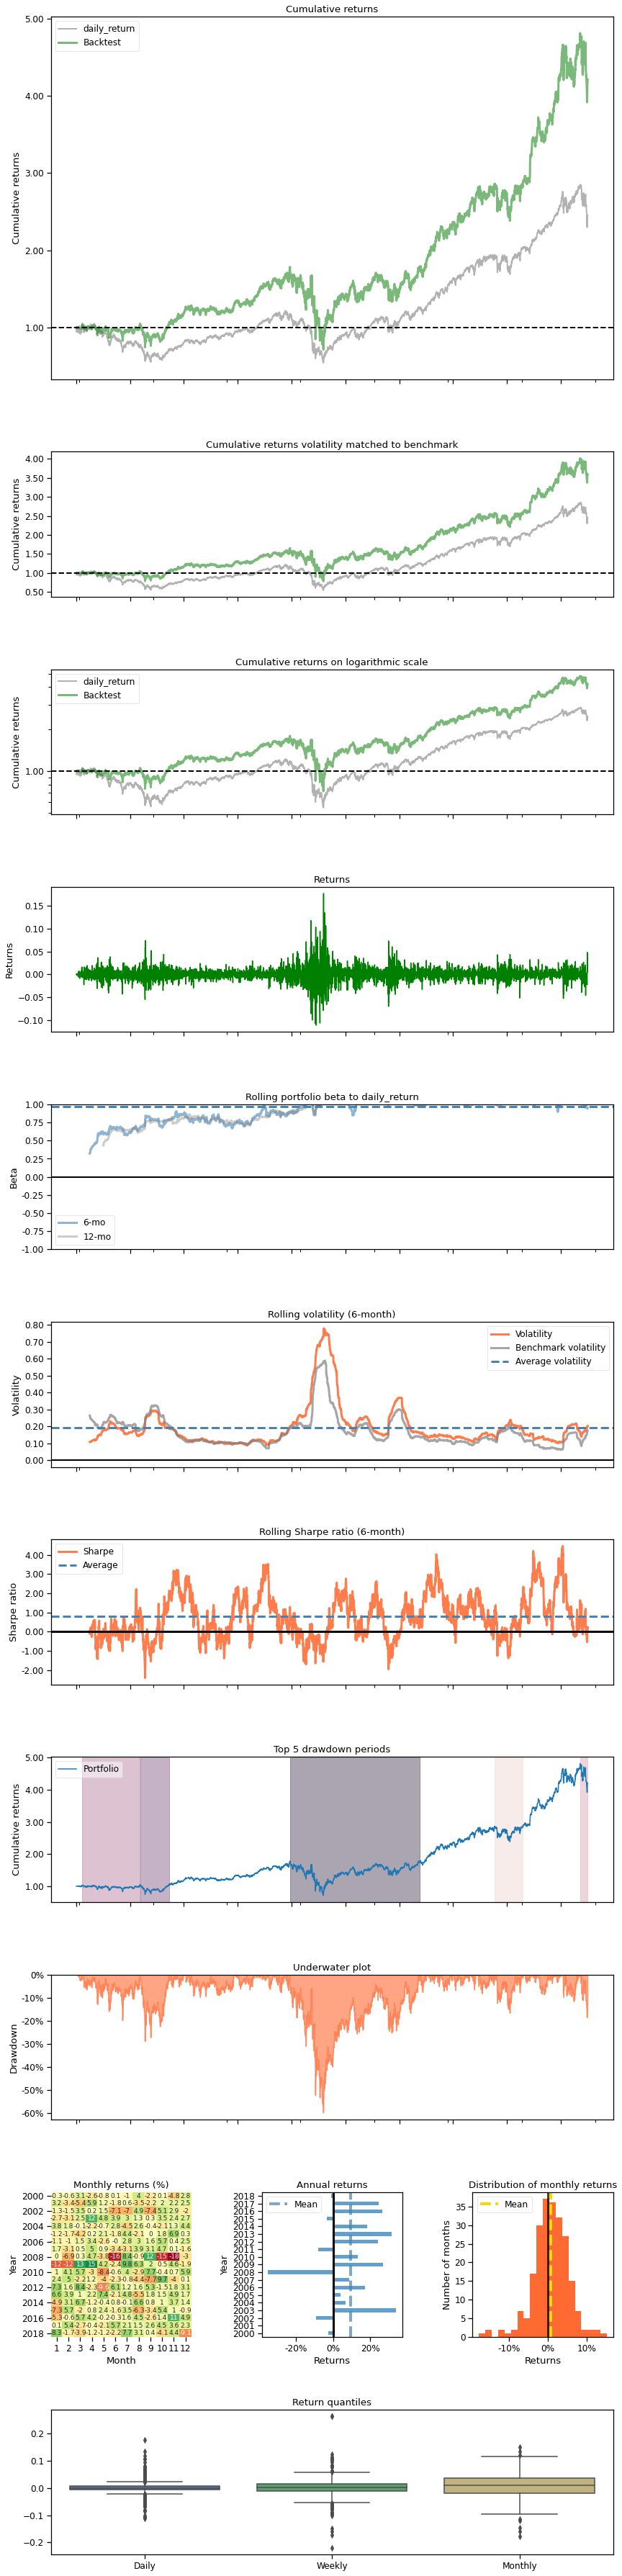

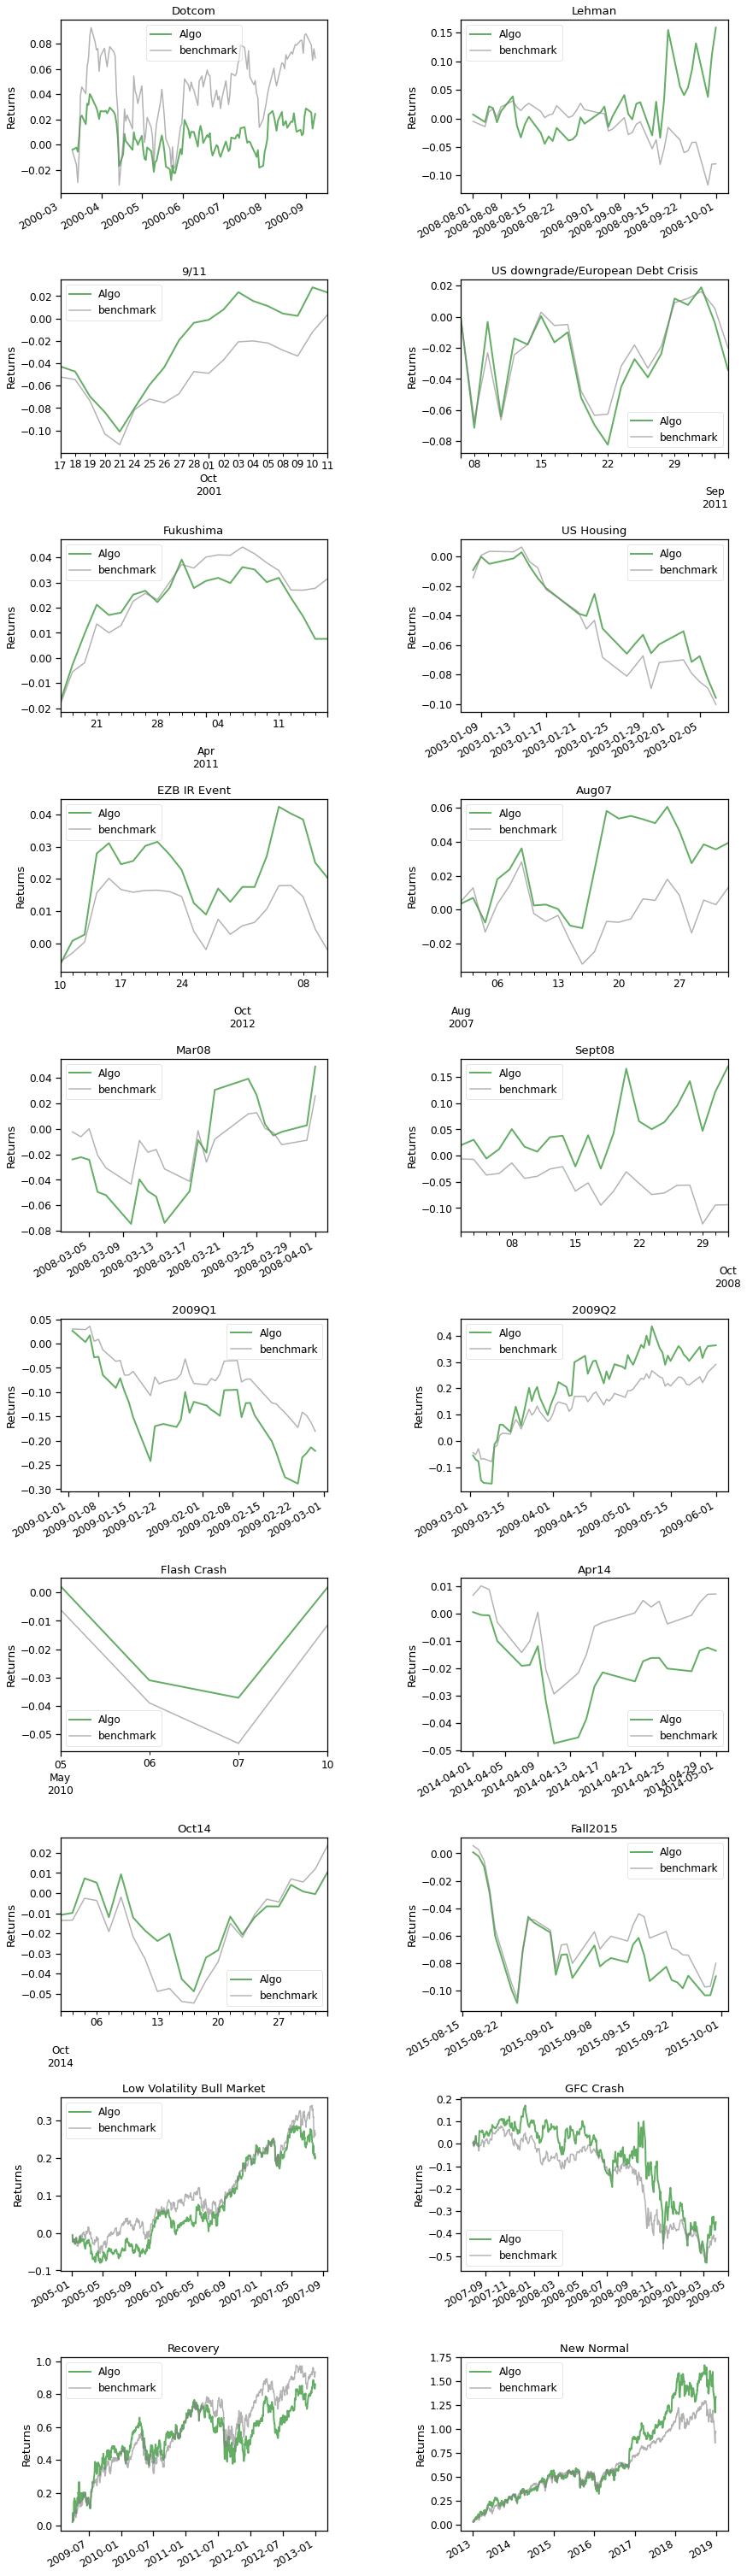

In [34]:
%matplotlib inline
backtest_plot(df_value['training_a2c'], baseline_ticker = 'SPY', baseline_start = start_date, baseline_end = split_date)

[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (4779, 8)


Start date,2000-01-03
End date,2018-12-31
Total months,227
,Backtest
Annual return,16.169%
Cumulative returns,1615.594%
Annual volatility,29.947%
Sharpe ratio,0.65
Calmar ratio,0.26
Stability,0.89
Max drawdown,-62.612%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,62.61,2007-10-23,2008-11-20,2009-10-26,525
1,53.70,2000-03-24,2002-10-09,2003-10-14,928
2,34.21,2018-09-04,2018-12-24,NaT,NaN
3,27.88,2015-12-29,2016-02-09,2016-05-10,96
4,27.58,2004-01-26,2004-10-25,2006-11-14,732


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


Stress Events,mean,min,max
Dotcom,-0.01%,-2.01%,2.76%
Lehman,-0.01%,-10.86%,12.20%
9/11,0.08%,-5.20%,4.54%
US downgrade/European Debt Crisis,0.19%,-6.22%,7.71%
Fukushima,0.34%,-1.62%,3.13%
US Housing,-0.36%,-2.28%,2.26%
EZB IR Event,-0.22%,-2.87%,2.52%
Aug07,0.18%,-3.36%,3.09%
Mar08,0.56%,-3.20%,6.63%
Sept08,-0.28%,-10.86%,12.20%


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


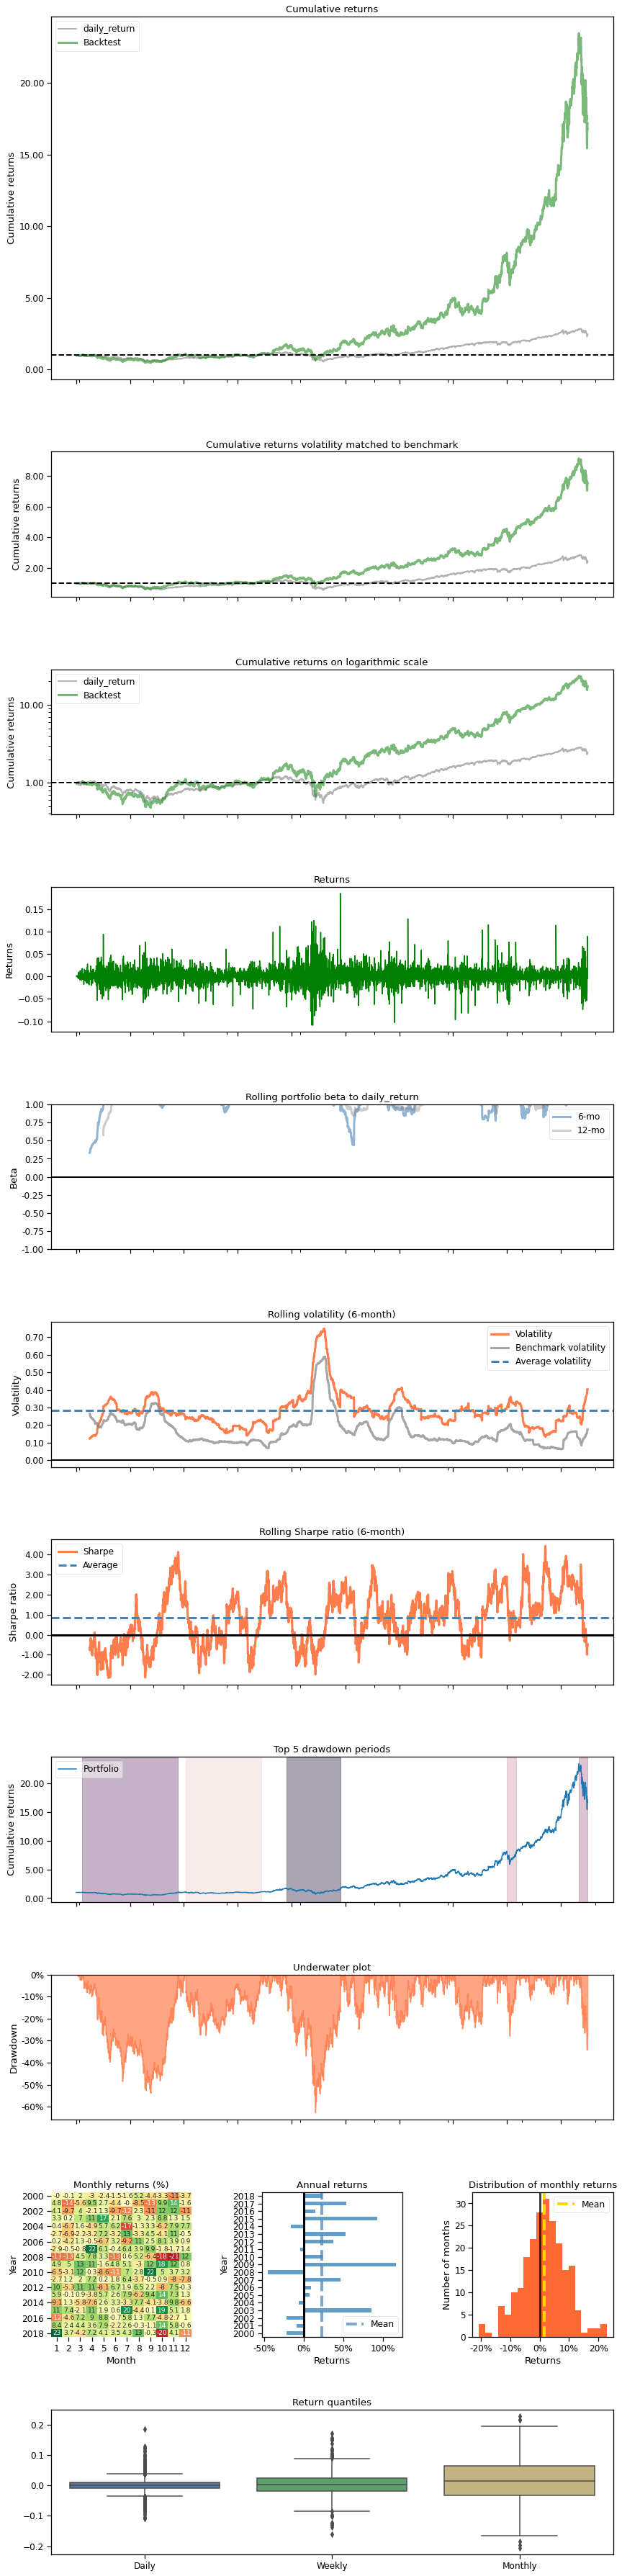

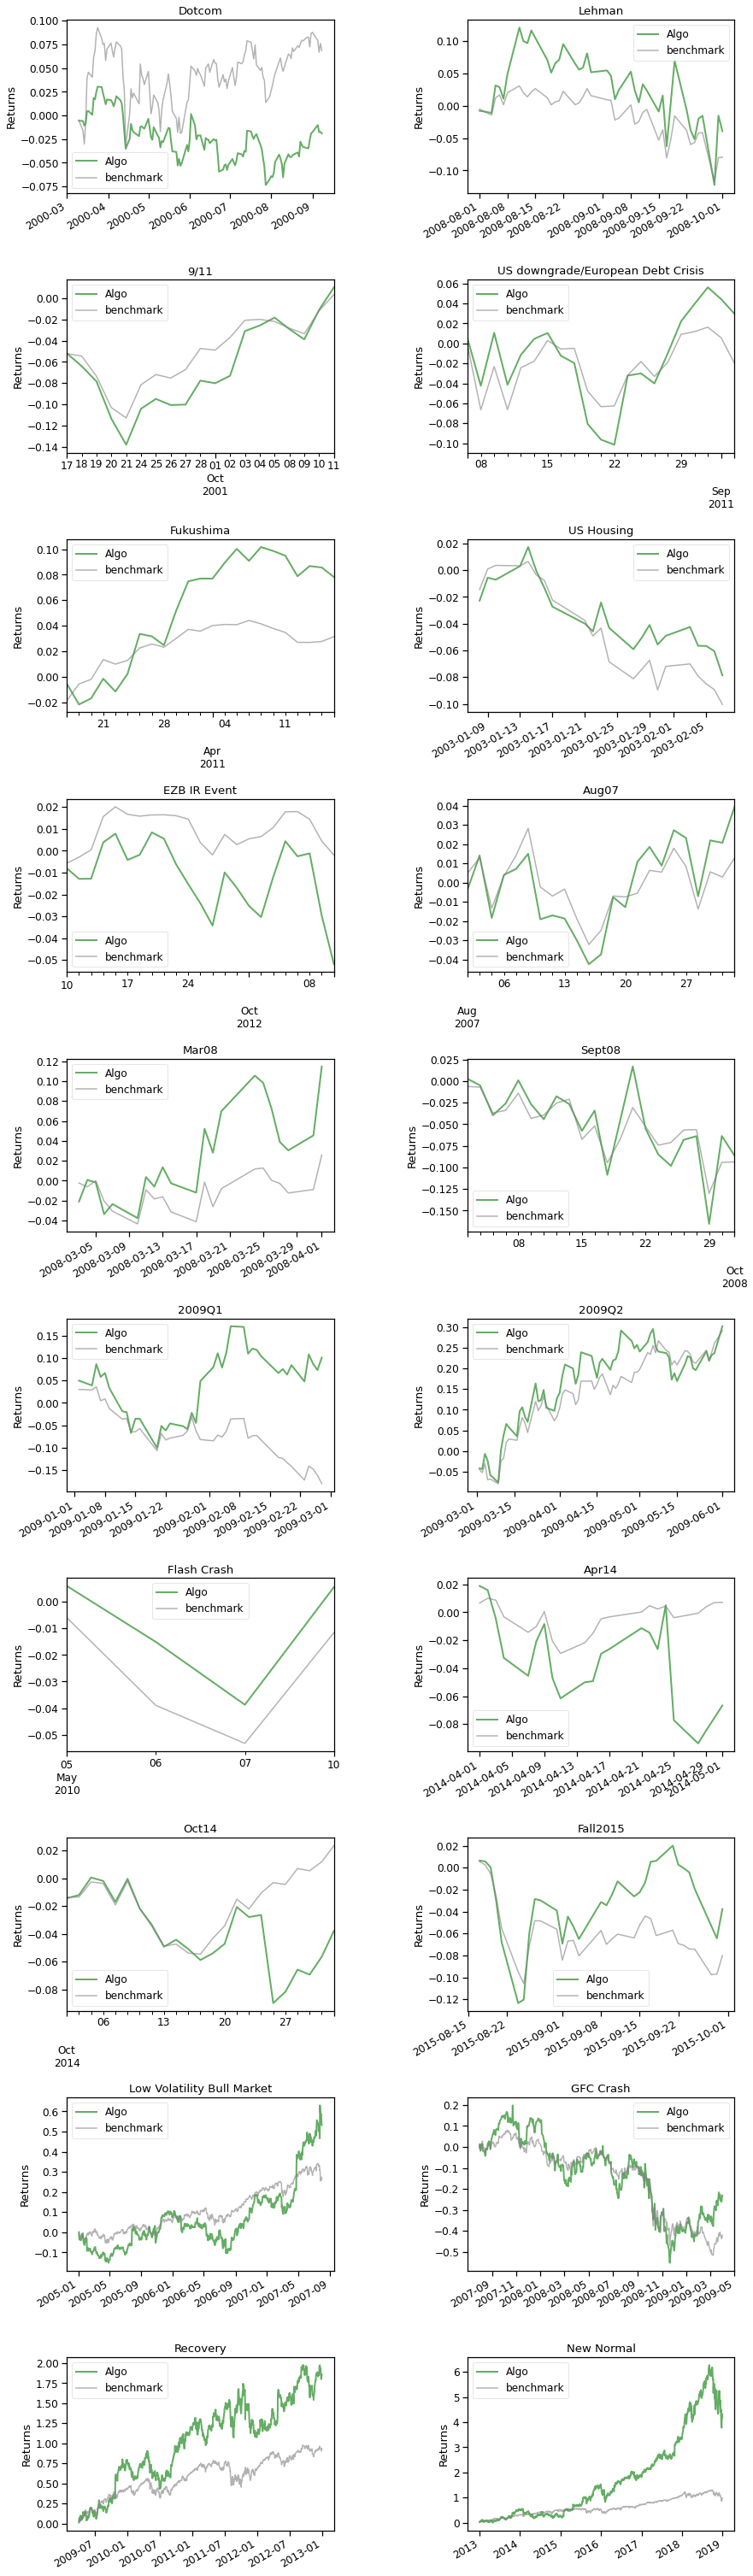

In [35]:
%matplotlib inline
backtest_plot(df_value['training_ppo'], baseline_ticker = 'SPY', baseline_start = start_date, baseline_end = split_date)

### Evaluation Performance

[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (505, 8)


Start date,2019-01-02
End date,2020-12-31
Total months,24
,Backtest
Annual return,20.465%
Cumulative returns,45.226%
Annual volatility,27.221%
Sharpe ratio,0.82
Calmar ratio,0.66
Stability,0.54
Max drawdown,-31.112%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,31.11,2020-02-19,2020-03-23,2020-09-02,141
1,7.94,2020-09-02,2020-10-28,2020-11-09,49
2,7.76,2019-04-30,2019-06-03,2019-06-28,44
3,7.41,2019-07-26,2019-08-14,2019-09-12,35
4,5.09,2019-09-13,2019-10-02,2019-10-25,31


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


Stress Events,mean,min,max
New Normal,0.09%,-11.57%,13.15%


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


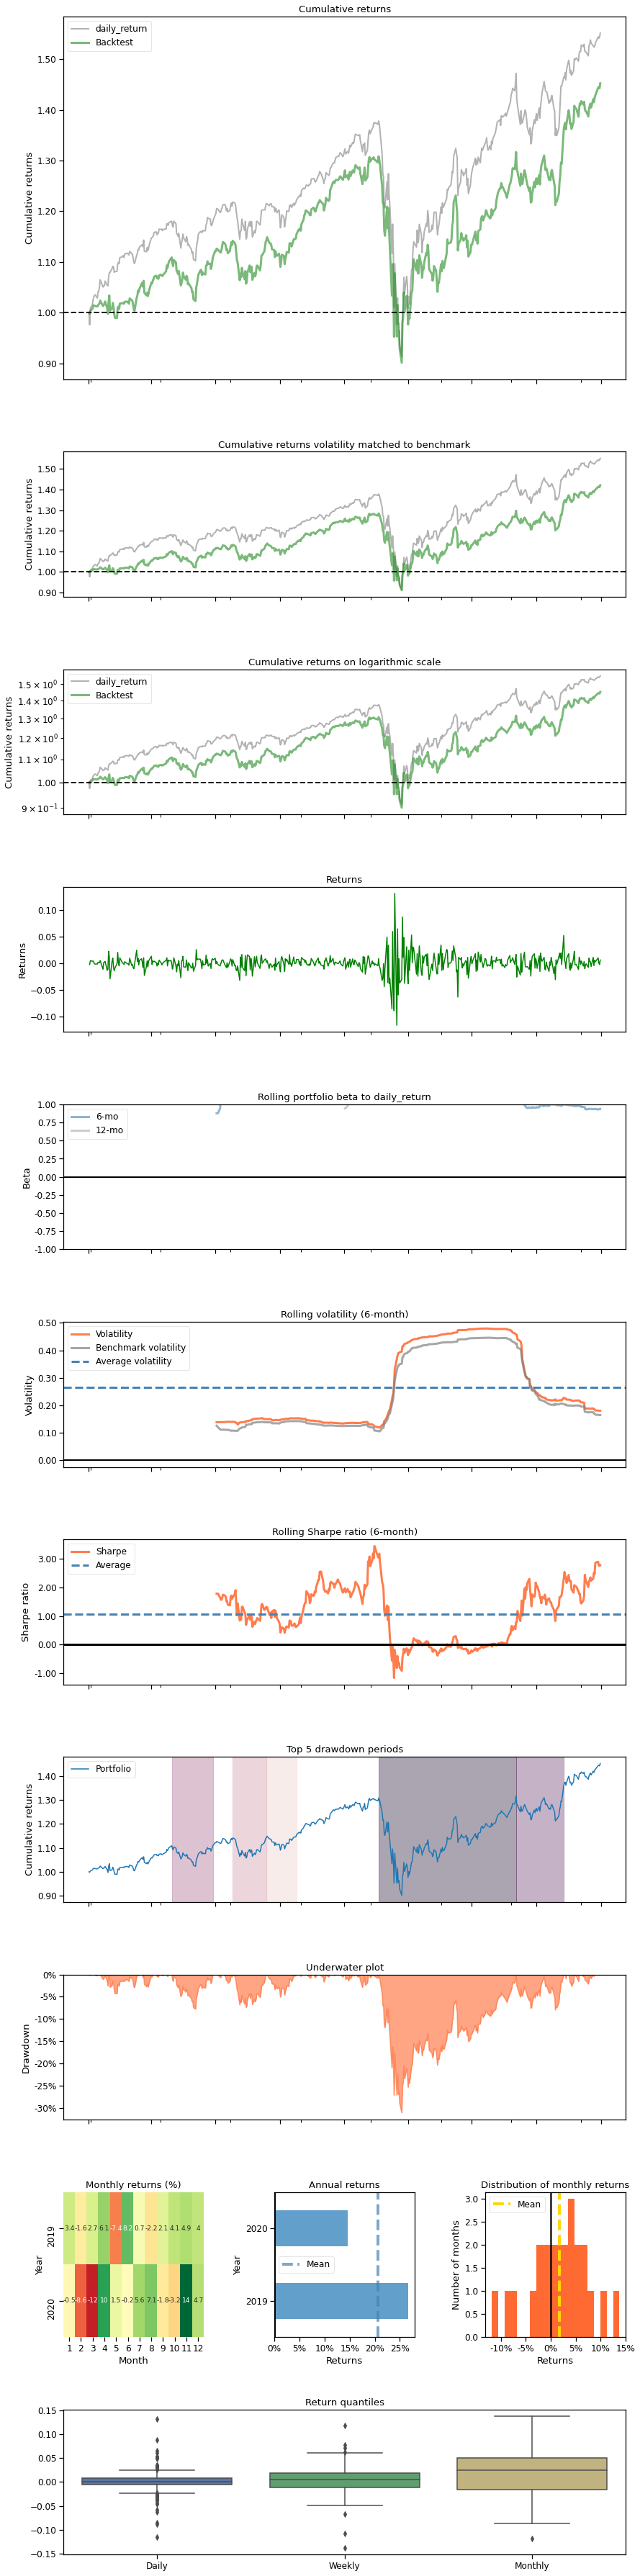

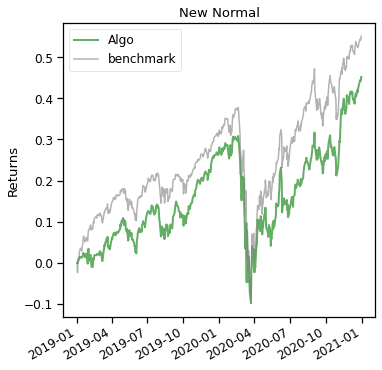

In [36]:
%matplotlib inline
backtest_plot(df_value['evaluation_a2c'], baseline_ticker = 'SPY', baseline_start = split_date, baseline_end = end_date)

[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (505, 8)


Start date,2019-01-02
End date,2020-12-31
Total months,24
,Backtest
Annual return,27.885%
Cumulative returns,63.706%
Annual volatility,25.494%
Sharpe ratio,1.09
Calmar ratio,1.10
Stability,0.85
Max drawdown,-25.325%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,25.33,2020-02-19,2020-03-23,2020-06-03,76
1,11.22,2020-09-02,2020-09-23,2020-10-12,29
2,8.94,2020-10-12,2020-10-30,NaT,NaN
3,8.93,2019-07-24,2019-08-14,2019-11-05,75
4,8.88,2019-04-26,2019-06-03,2019-06-19,39


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


Stress Events,mean,min,max
New Normal,0.11%,-9.19%,8.67%


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


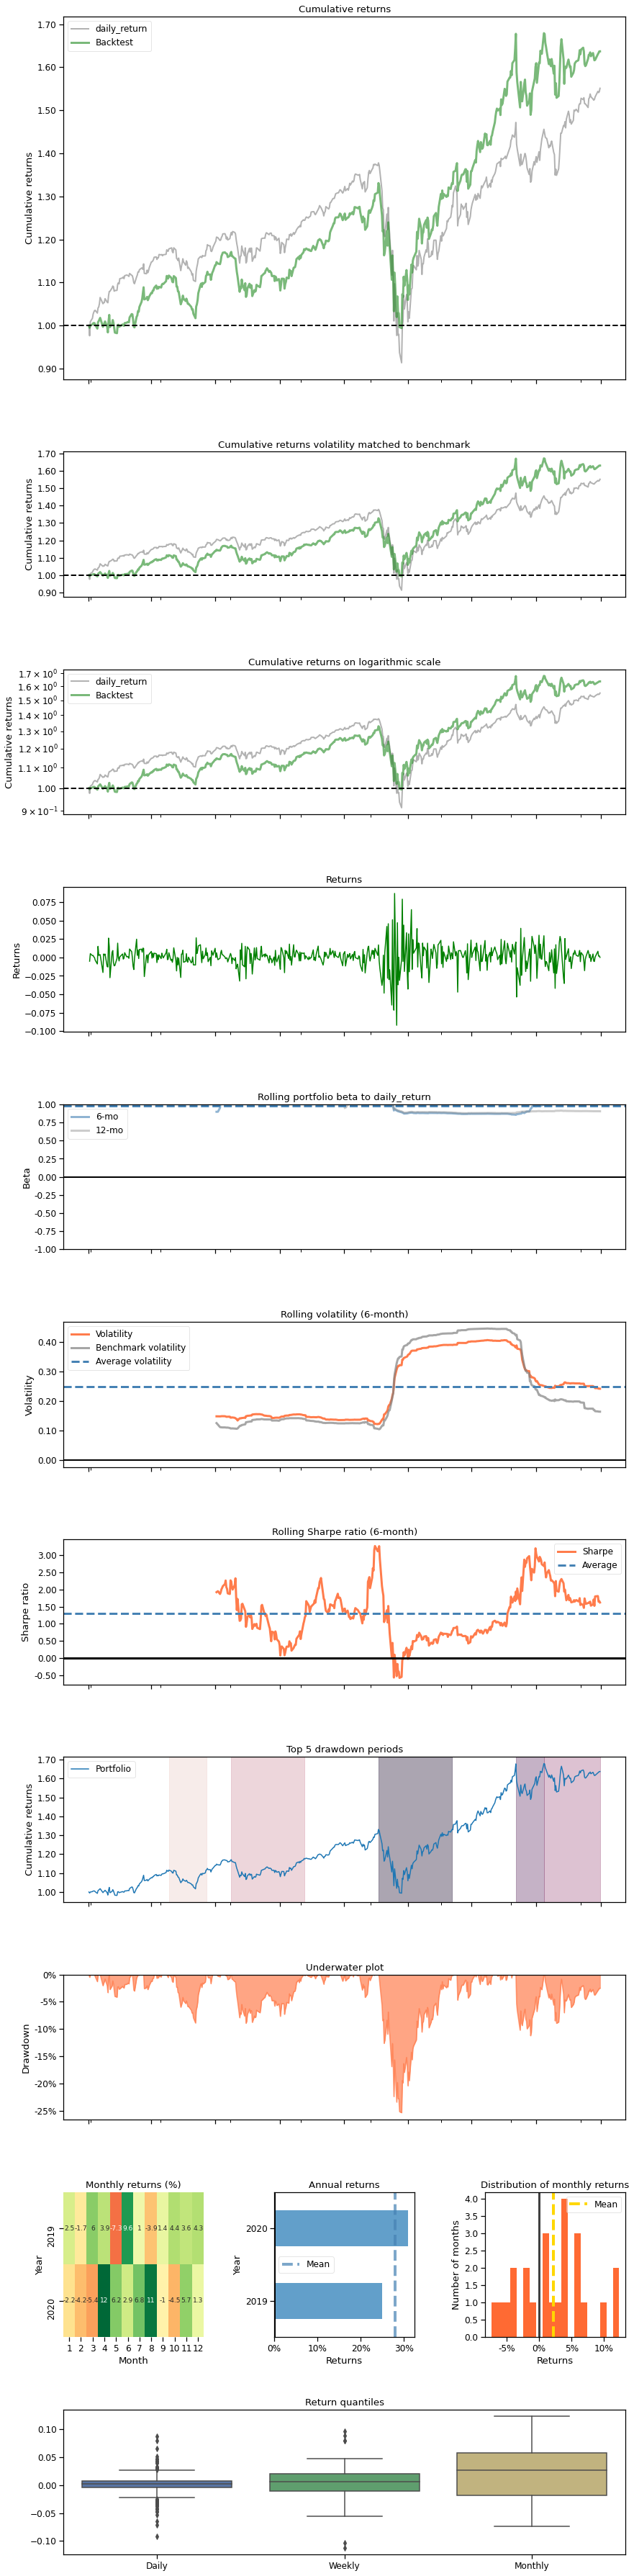

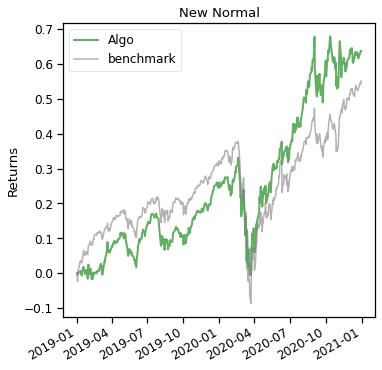

In [37]:
%matplotlib inline
backtest_plot(df_value['evaluation_ppo'], baseline_ticker = 'SPY', baseline_start = split_date, baseline_end = end_date)

[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (505, 8)


Start date,2019-01-02
End date,2020-12-31
Total months,24
,Backtest
Annual return,55.512%
Cumulative returns,142.263%
Annual volatility,36.946%
Sharpe ratio,1.38
Calmar ratio,1.66
Stability,0.88
Max drawdown,-33.516%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,33.52,2020-02-19,2020-03-16,2020-05-18,64
1,19.21,2019-04-23,2019-06-03,2019-10-25,134
2,14.60,2020-09-02,2020-09-08,NaT,NaN
3,6.00,2020-06-10,2020-06-11,2020-06-22,9
4,5.38,2019-01-25,2019-01-29,2019-02-06,9


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


Stress Events,mean,min,max
New Normal,0.20%,-15.28%,12.54%


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


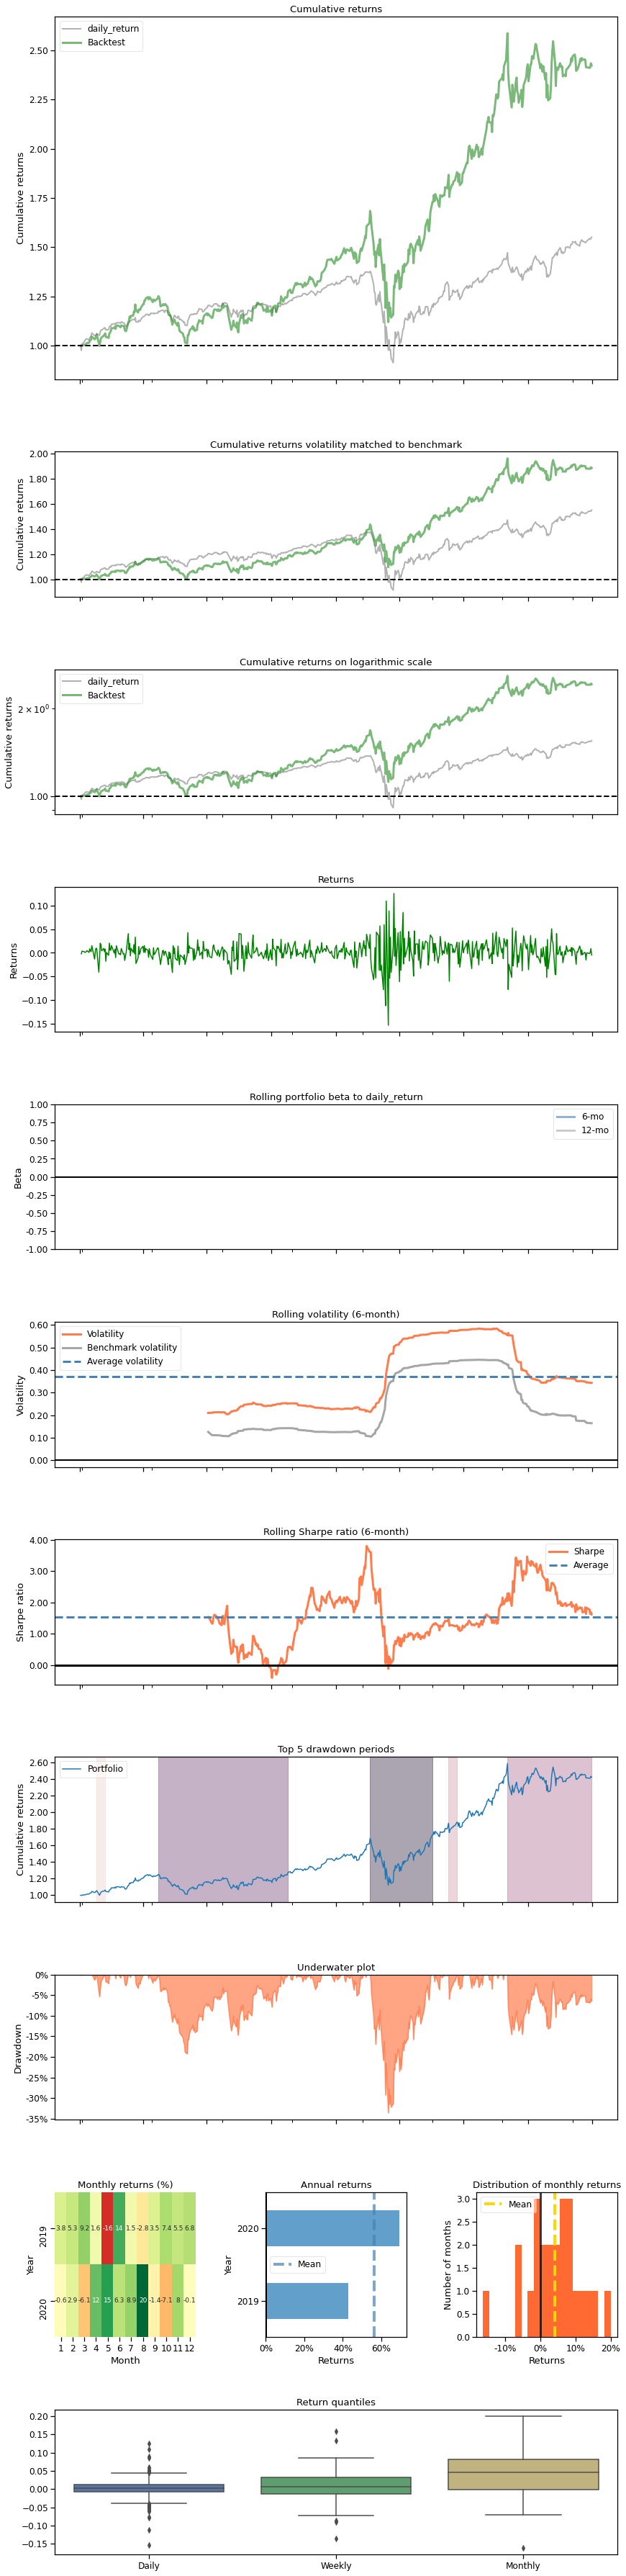

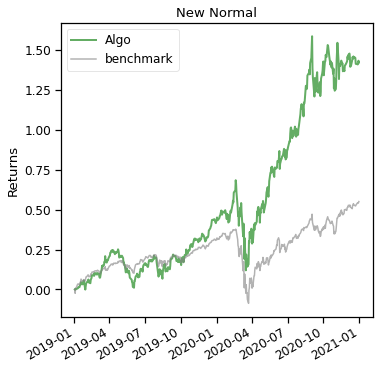

In [38]:
%matplotlib inline
backtest_plot(df_value['evaluation_ddpg'], baseline_ticker = 'SPY', baseline_start = split_date, baseline_end = end_date)

[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (505, 8)


Start date,2019-01-02
End date,2020-12-31
Total months,24
,Backtest
Annual return,42.003%
Cumulative returns,101.928%
Annual volatility,28.698%
Sharpe ratio,1.37
Calmar ratio,1.66
Stability,0.83
Max drawdown,-25.235%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,25.23,2020-02-19,2020-03-16,2020-04-16,42
1,14.47,2020-09-02,2020-09-18,NaT,NaN
2,13.06,2019-05-03,2019-06-03,2019-07-09,48
3,11.23,2019-07-15,2019-08-14,2020-01-02,124
4,6.12,2020-04-30,2020-05-01,2020-05-18,13


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


Stress Events,mean,min,max
New Normal,0.16%,-8.67%,8.16%


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


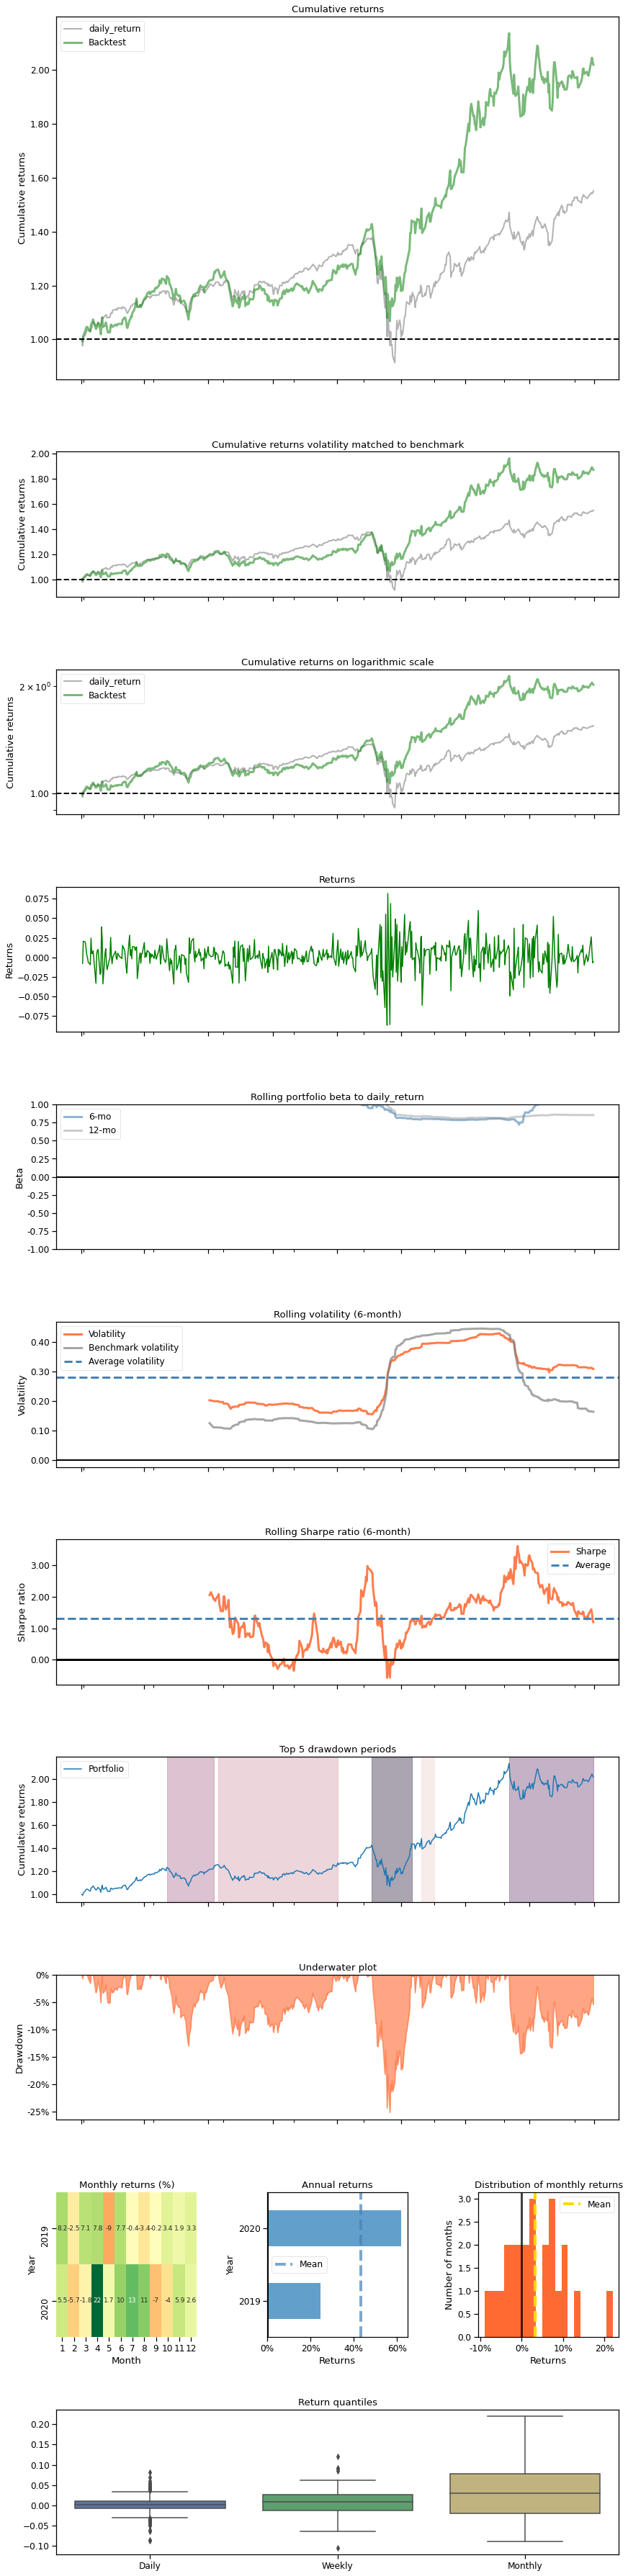

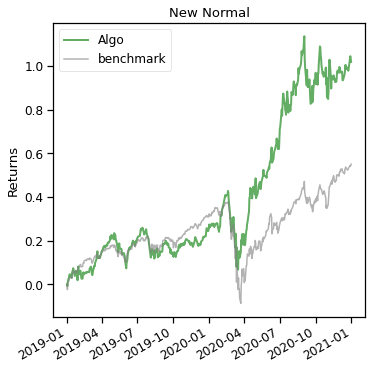

In [39]:
%matplotlib inline
backtest_plot(df_value['evaluation_td3'], baseline_ticker = 'SPY', baseline_start = split_date, baseline_end = end_date)

[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (505, 8)


Start date,2019-01-02
End date,2020-12-31
Total months,24
,Backtest
Annual return,38.949%
Cumulative returns,93.321%
Annual volatility,27.765%
Sharpe ratio,1.33
Calmar ratio,1.61
Stability,0.83
Max drawdown,-24.19%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,24.19,2020-02-19,2020-03-16,2020-04-16,42
1,13.43,2020-09-02,2020-09-21,NaT,NaN
2,12.21,2019-07-15,2019-10-02,2020-01-02,124
3,10.57,2019-05-03,2019-06-03,2019-07-02,43
4,5.62,2020-04-30,2020-05-01,2020-05-19,14


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


Stress Events,mean,min,max
New Normal,0.15%,-9.22%,9.06%


D:\InstalledSoftware\anaconda3\envs\py37-python-notebook\lib\site-packages\pandas\core\indexes\base.py:5277: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version.  Use a timezone-aware object instead.
  start_slice, end_slice = self.slice_locs(start, end, step=step, kind=kind)


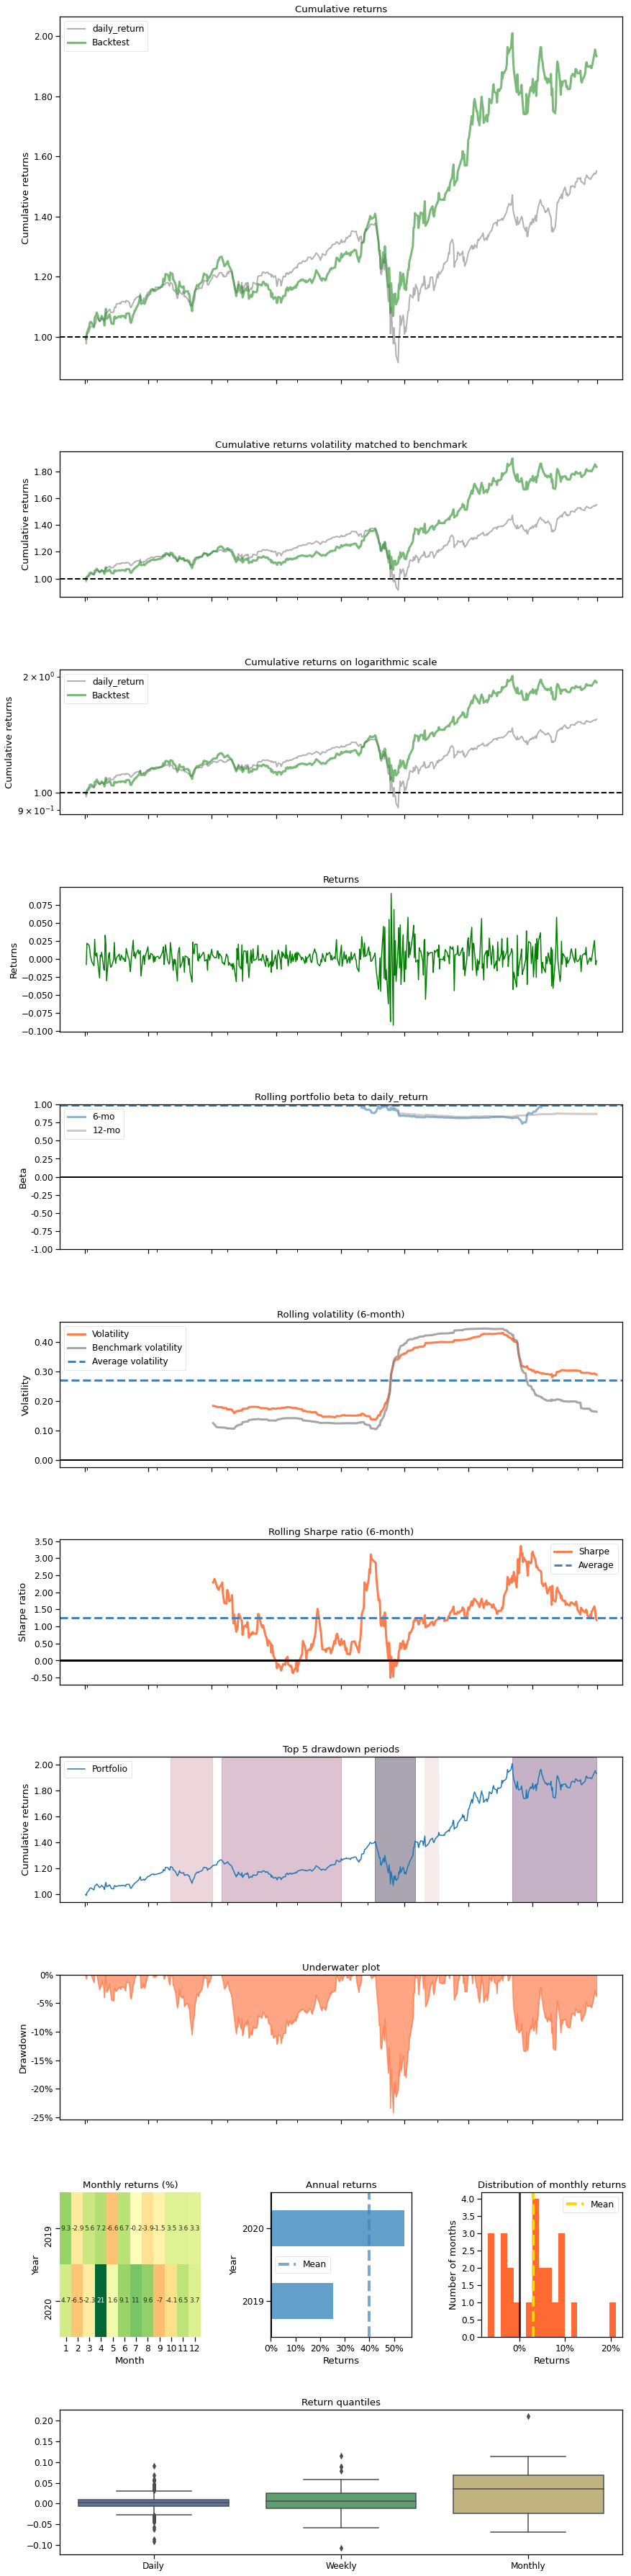

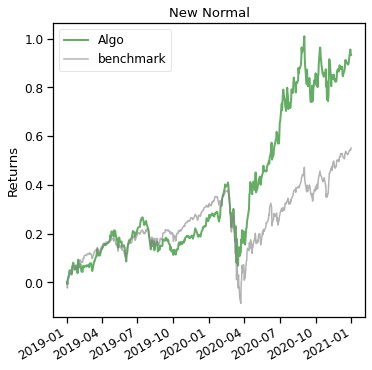

In [40]:
%matplotlib inline
backtest_plot(df_value['evaluation_sac'], baseline_ticker = 'SPY', baseline_start = split_date, baseline_end = end_date)